# DDPG: Deep Deterministic Policy Gradient (Continuous Actions)

DDPG is designed for continuous action spaces - critical for finance.
It combines DQN's experience replay and target networks with a deterministic actor

- **Actor** $\pi^D(s;\theta)$: deterministic policy, updated via sampled policy gradient
- **Critic** $Q(s,a;\phi)$: Q-function, updated via TD target from frozen target networks

Exploration uses additive noise: $a_t \sim \pi^D(s_t;\theta_t) + \varepsilon$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import deque
import torch
import torch
import torch.nn as nn
import torch.optim as optim 

random.seed(24)
np.random.seed(24)

### Reply Buffer class from DQN model

In [2]:
class ReplayBuffer:
    """Experience replay buffer B"""
    def __init__(self, capacity=10000):
        self.buf = deque(maxlen=capacity)
    def push(self, s, a, r, s_next, done):
        self.buf.append((s, a, r, s_next, done))
    def sample(self, batch_size):
        batch = random.sample(self.buf, batch_size)
        s, a, r, s_next, done = zip(*batch)
        # Handle both int actions (DQN) and float actions (DDPG)
        try:
            a_t = torch.LongTensor(np.array(list(a), dtype=np.int64))
        except (TypeError, ValueError):
            a_t = torch.FloatTensor(np.array(list(a), dtype=np.float32))
        return (torch.FloatTensor(np.array(list(s), dtype=np.float32)),
                a_t,
                torch.FloatTensor(np.array(list(r), dtype=np.float32)),
                torch.FloatTensor(np.array(list(s_next), dtype=np.float32)),
                torch.FloatTensor(np.array(list(done), dtype=np.float32)))
    def __len__(self): return len(self.buf)

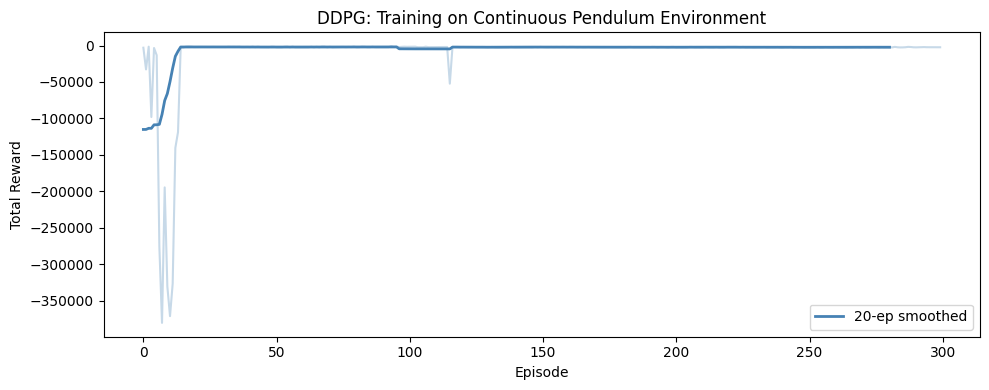

DDPG final smoothed reward: -2357.1


In [3]:
class Actor(nn.Module):
    """Deterministic policy network: state -> action in [-1, 1]"""
    def __init__(self, state_dim, action_dim, hidden=128, action_scale=1.0):
        super().__init__()
        self.scale = action_scale
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, action_dim), nn.Tanh()
        )
    def forward(self, x): return self.net(x) * self.scale

class Critic(nn.Module):
    """Q-function network: (state, action) -> Q-value"""
    def __init__(self, state_dim, action_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential( nn.Linear(state_dim + action_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, 1)
        )
    def forward(self, s, a): return self.net(torch.cat([s, a], dim=-1))

def soft_update(source, target, tau):
    """Soft update of target network: theta^- <- tau*theta + (1-tau)*theta^-."""
    for sp, tp in zip(source.parameters(), target.parameters()):
        tp.data.copy_(tau * sp.data + (1 - tau) * tp.data)


class PendulumEnv:
    """
    Simple pendulum stabilization environment (continuous actions)
    State: [cos(theta), sin(theta), theta_dot]
    Action: torque in [-max_torque, max_torque]
    Reward: -(theta^2 + 0.1*theta_dot^2 + 0.001*torque^2)
    """
    def __init__(self, max_torque=2.0, dt=0.05):
        self.max_torque = max_torque
        self.dt = dt
        self.g, self.m, self.l = 10.0, 1.0, 1.0
        self.state_dim = 3
        self.action_dim = 1

    def reset(self):
        theta = np.random.uniform(-np.pi, np.pi)
        theta_dot = np.random.uniform(-1, 1)
        self.theta, self.theta_dot = theta, theta_dot
        return self._get_obs()

    def _get_obs(self):
        return np.array([np.cos(self.theta), np.sin(self.theta), self.theta_dot], dtype=np.float32)

    def step(self, action):
        u = np.clip(action[0], -self.max_torque, self.max_torque)
        g, m, l, dt = self.g, self.m, self.l, self.dt
        new_theta_dot = self.theta_dot + (-3*g/(2*l)*np.sin(self.theta+np.pi) + 3/(m*l**2)*u) * dt
        new_theta = self.theta + new_theta_dot * dt
        new_theta_dot = np.clip(new_theta_dot, -8, 8)
        self.theta, self.theta_dot = new_theta, new_theta_dot
        reward = -(self.theta**2 + 0.1*self.theta_dot**2 + 0.001*u**2)
        return self._get_obs(), reward, False   # never done


def ddpg(env, num_episodes=300, episode_len=200, gamma=0.99, lr_actor=1e-4,
            lr_critic=1e-3, batch_size=64, buffer_size=100000,
            tau=0.005, noise_std=0.1):
    """
    DDPG - Deep Deterministic Policy Gradient,
    Suitable for continuous action spaces.
    """
    s_dim = env.state_dim
    a_dim = env.action_dim
    a_scale = env.max_torque

    actor = Actor(s_dim, a_dim, action_scale=a_scale)
    critic = Critic(s_dim, a_dim)
    actor_tgt = Actor(s_dim, a_dim, action_scale=a_scale)
    critic_tgt = Critic(s_dim, a_dim)
    actor_tgt.load_state_dict(actor.state_dict())
    critic_tgt.load_state_dict(critic.state_dict())

    opt_actor = optim.Adam(actor.parameters(), lr=lr_actor)
    opt_critic = optim.Adam(critic.parameters(), lr=lr_critic)
    replay = ReplayBuffer(buffer_size)
    rewards_hist = []

    for ep in range(num_episodes):
        s = env.reset()
        ep_reward = 0

        for _ in range(episode_len):
            # Action with exploration noise
            with torch.no_grad():
                a = actor(torch.FloatTensor(s)).numpy()
            a += noise_std * np.random.randn(a_dim)
            a = np.clip(a, -a_scale, a_scale)

            s_next, r, done = env.step(a)
            ep_reward += r
            replay.push(s, a, [r], s_next, [float(done)])
            s = s_next

            if len(replay) < batch_size:
                continue

            s_b, a_b, r_b, sn_b, d_b = replay.sample(batch_size)

            # Critic update
            with torch.no_grad():
                a_next = actor_tgt(sn_b)
                Y = r_b + gamma * critic_tgt(sn_b, a_next) * (1 - d_b)

            Q_curr = critic(s_b, a_b)
            critic_loss = nn.MSELoss()(Q_curr, Y)
            opt_critic.zero_grad(); critic_loss.backward(); opt_critic.step()

            # Actor update
            actor_loss = -critic(s_b, actor(s_b)).mean()
            opt_actor.zero_grad(); actor_loss.backward(); opt_actor.step()

            # Soft update target networks
            soft_update(actor, actor_tgt, tau)
            soft_update(critic, critic_tgt, tau)

        rewards_hist.append(ep_reward)

    return actor, critic, rewards_hist


pendulum = PendulumEnv()
actor_ddpg, critic_ddpg, rewards_ddpg = ddpg(pendulum, num_episodes=300)

window = 20
smooth_ddpg = np.convolve(rewards_ddpg, np.ones(window)/window, mode='valid')
plt.figure(figsize=(10, 4))
plt.plot(rewards_ddpg, alpha=0.3, color='steelblue')
plt.plot(smooth_ddpg, color='steelblue', linewidth=2, label='20-ep smoothed')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('DDPG: Training on Continuous Pendulum Environment')
plt.legend()
plt.tight_layout()
plt.show()
print(f"DDPG final smoothed reward: {smooth_ddpg[-1]:.1f}")